In [69]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *
from hazcalc import *

In [70]:
# Simple site
x_site, y_site = 0., 0.
vs30 = 760
z1p0, z2p5 = 1.3, 0.
site = Site(x_site, y_site, vs30, z1p0, z2p5, 0.)

# Fault 1 is large, faraway earthquakes; fault 2 is small, close
x_fault1, y_fault1 = 50., 49.
theta1, width1 = 225, 1.5
mfd1, M_marg1 = MFD(2.5, 1.25), jnp.array([7., 8.5])
x_fault2, y_fault2 = -20., 15.
theta2, width2 = 30, 2.7
mfd2, M_marg2 = MFD(4.1, 1.8), jnp.array([5., 6.])
# Shared fault params
z_hyp = 1.5
z_tor = 1.
dip = 45
rake = 0.
# Fault 1
fault1 = Fault(x_fault1, x_fault2, z_hyp, z_tor, theta1, dip, rake, width1, 0., mfd1)
fault2 = Fault(x_fault2, y_fault2, z_hyp, z_tor, theta2, dip, rake, width2, 0., mfd2)
faults = [fault1, fault2]
# Scenario magnitude tree
M_margs = jnp.stack([M_marg1, M_marg2])

# GMMs
gmms = [gmm_ASK14, gmm_BSSA14, gmm_CB14, gmm_CY14, gmm_Idriss14]
c_AAY14 = 1.674
gmms = gmms + [gmm_epi_AAY14(gmm, c_AAY14) for gmm in gmms] + [gmm_epi_AAY14(gmm, -c_AAY14) for gmm in gmms]
# GMM weights
w_gmms = jnp.ones(len(gmms)) / len(gmms)
gmmlt = GMMLT(gmms, w_gmms)

# Intensity measures + period
n_ims = 16
ims = jnp.logspace(-3, -1, n_ims, base = 10)
im0 = (ims[-1] + ims[0])/2
T = 0.1

In [71]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
from jax.scipy.stats.norm import cdf as norm_cdf

# This
from numerics import *
from seismic import *

from jax.experimental.jet import jet
from jax.scipy.special import factorial

from collections.abc import Callable

@jtu.register_pytree_node_class
class PCE:
    def __init__(self, f:Callable,
                 k_PCE:int = 5, 
                 strategy:str = 'hyperbolic', 
                 q:float = 0.625, order_matters:bool = True, 
                 alpha:float|jax.Array = 1.,):
        self.f = f
        self.k_PCE = k_PCE
        self.strategy = strategy
        self. q = q
        self.order_matters = order_matters
        self.alpha = alpha
    
    def calc_coeffs(self, x:jax.Array, *f_args):
        def fx(xi):
            return self.f(xi, *f_args)
        d = x.shape[-1]
        y = jax.vmap(fx)(x)
        H = mv_psi(x, 'H', 
                   self.k_PCE, self.strategy, 
                   self.q, self.order_matters, 
                   self.alpha)
        H_norm2 = jnp.vecdot(H, H, axis = 0)
        c = (H.T @ y) / H_norm2
        return c
    
    def eval_coeffs(self, xi:jax.Array, c:jax.Array):
        Hi = mv_psi(xi, 'H', 
                   self.k_PCE, self.strategy, 
                   self.q, self.order_matters, 
                   self.alpha)
        return Hi @ c
    
    def tree_flatten(self):
        leaves = (self.alpha,)
        aux = (self.f, self.k_PCE, 
               self.strategy, self.q, self.order_matters)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        f, k_PCE, strategy, q, order_matters = aux
        (alpha,) = leaves
        return cls(f,
                   k_PCE=k_PCE, strategy=strategy,
                   q=q, order_matters=order_matters,
                   alpha=alpha)


@jtu.register_pytree_node_class
class tPCE:
    def __init__(self, f:Callable, 
                 k_taylor:int = 5, k_PCE:int = 5, 
                 strategy:str = 'hyperbolic',
                 q:float = 0.625, order_matters:bool = True,
                 alpha:float|jax.Array = 1.):
        self.f = f
        self.k_taylor = k_taylor
        self.k_PCE = k_PCE
        self.strategy = strategy
        self. q = q
        self.order_matters = order_matters
        self.alpha = alpha
    
    def calc_coeffs(self, z0:float, x:jax.Array, *f_args):
        def one_jet(xi, *args):
                def fz(zi):
                    return self.f(zi, xi, *args)
                return jet(fz, (z0,), ((1,) + (0,) * (self.k_taylor - 1),))

        # Hermite polynomials
        H = mv_psi(x, 'H', 
                   self.k_PCE, self.strategy, 
                   self.q, self.order_matters, 
                   self.alpha)

        # Take derivatives of fz
        y_z0, dnydzn_z0 = jax.vmap(one_jet, in_axes = (0,) + (None,) * len(f_args))(x, *f_args)
        dnydzn_z0 = jnp.stack([y_z0, *dnydzn_z0])

        # Use least-squares to get Taylor series coefficient derivatives by chain rule
        #   (lstsq is a linear operator) at z0
        H_norm2 = jnp.vecdot(H, H, axis = 0)
        c = (H.T @ dnydzn_z0.T) / H_norm2[:, None]

        # Evaluate taylor coefficients
        def eval_c(z:float):
            """
            Evaluate the tPCE coefficient array at a given deterministic input z.

            Combines the least-squares PCE coefficient matrix c with a monomial
            Taylor basis evaluated at (z - z0), weighted by factorial denominators,
            to return the effective PCE coefficients for the scalar value z.

            Args:
                z: Scalar deterministic input at which to evaluate the Taylor expansion.

            Returns:
                Array of shape (P, ...) containing the PCE coefficients at z.
            """
            # Monomials for taylor expansion
            transf_zM = uv_psi(z - z0, 'M', self.k_taylor + 1)
            # Factorial denominator
            denom = factorial(jnp.arange(self.k_taylor + 1))
            # Bam
            return c @ (transf_zM / denom)

        return eval_c
    
    def eval_coeffs(self, zi:float, xi:jax.Array, eval_c:Callable):
        Hi = mv_psi(xi, 'H', 
                   self.k_PCE, self.strategy, 
                   self.q, self.order_matters, 
                   self.alpha)
        c = eval_c(zi)
        return Hi @ c
    
    def tree_flatten(self):
        leaves = (self.alpha,)
        aux = (self.f, self.k_taylor, self.k_PCE,
               self.strategy, self.q, self.order_matters)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        f, k_taylor, k_PCE, strategy, q, order_matters = aux
        (alpha,) = leaves
        return cls(f, 
                   k_taylor=k_taylor, k_PCE=k_PCE, strategy=strategy,
                   q=q, order_matters=order_matters,
                   alpha=alpha)

def _faults_to_tree(faults:list[Fault])->Fault:
    return jt.map(lambda *xs: jnp.stack(xs), *faults)

@jtu.register_pytree_node_class
class HazCalculator:
    """
    Probabilistic Seismic Hazard Analysis (PSHA) Calculator

    This class provides methods for calculating seismic hazard using a logic tree of Ground Motion Models (GMMs).
    It supports incremental and marginal hazard calculations, ground motion evaluation, and epistemic uncertainty
    quantification for PSHA applications.

    Attributes
    ----------
    gmmlt : GMMLT
        The logic tree of Ground Motion Models (GMMs) with associated weights.
    dM : float, optional
        The magnitude bin size for discretizing the magnitude-frequency distribution (default is 0.01).

    Methods
    -------
    haz_calc_n_M_incr(scn: Scenario)
        Computes incremental rupture rates (number of events per bin) for all faults and magnitude bins.
    mhaz_calc_n_M_incr(M: float, scn: Scenario)
        Computes marginal incremental rupture rates for a specific magnitude M.
    haz_calc_all_lnSA(scn: Scenario)
        Calculates the mean and standard deviation of the natural logarithm of spectral acceleration (lnSA)
        for all GMMs, faults, and magnitude bins.
    mhaz_calc_all_lnSA(M: float, scn: Scenario)
        Calculates the mean and standard deviation of lnSA for all GMMs and faults at a specific magnitude M.
    haz_calc_haz_from_lnSA(im: jax.Array, all_mu_lnSA: jax.Array, all_std_lnSA: jax.Array, all_w: jax.Array, n_M_incr: jax.Array)
        Computes the total hazard curve (annual frequency of exceedance) for a given intensity measure (IM)
        using the computed lnSA statistics and incremental rates.
    haz_calc_epi_from_lnSA(im: jax.Array, all_mu_lnSA: jax.Array, all_std_lnSA: jax.Array, all_w: jax.Array, n_M_incr: jax.Array, ddof: int = 0)
        Computes epistemic uncertainty (weighted standard deviation) in the hazard curve due to logic tree weights.
    tree_flatten()
        Flattens the HazCalculator object for JAX pytree compatibility.
    tree_unflatten(aux, children)
        Reconstructs a HazCalculator object from flattened components for JAX pytree compatibility.
    """
    def __init__(self, gmmlt:GMMLT, dM:float = 0.01):
        """Initialize with GMMs and a bin size"""
        self.gmmlt = gmmlt
        self.dM = dM

    #### HELPERS ####
    def _calc_M_n_M_bins(self, fault_tree:Fault, M_ranges:jax.Array|None = None):
        # Magnitude bins.
        M_min = fault_tree.mfd.M_min if M_ranges is None else M_ranges[:,0]
        M_max = fault_tree.mfd.M_max if M_ranges is None else M_ranges[:,1]
        bins_M = jnp.arange(M_min.min(), M_max.max() + self.dM, self.dM)
        # MFD exceedance rates
        n_M_exc = jax.vmap(fault_tree.mfd.calc_lmdaM)(bins_M)
        # MFD incremental rates
        n_M_incr = n_M_exc[:-1] - n_M_exc[1:]
        # Roots for GMM evaluation.
        roots_M = (bins_M[:-1] + bins_M[1:]) / 2
        # Array of ones/zeros for each fault signifying array inside/outside range
        weights_mask = (roots_M[:, None] > M_min[None, :]) & (roots_M[:, None] < M_max[None, :])
        # We can think of our incremental rates as already including quadrature weights, so 
        #   we'll just multiply them by the mask.
        n_M_incr = n_M_incr * weights_mask
        # Mask out values that aren't selected for either fault
        M_mask = jnp.any(weights_mask, axis = -1)
        return roots_M, n_M_incr, M_mask
    
    def _calc_exc_im(self, im:float, mu_lnSA:jax.Array, std_lnSA:jax.Array):
        # Calculate cumulative probability
        cum_prob_im = norm_cdf(jnp.log(im), loc = mu_lnSA, scale = std_lnSA)
        # Note that we SHOULD implement a 3-sigma upper bound here, but it appears to be
        #   incompatible with jax.jet...
        return 1 - cum_prob_im

    #### HAZARD CALC ####
    def calc_haz(self, im:jax.Array, T:float, site:Site, faults:list[Fault], M_ranges:jax.Array|None = None):
        # Get rates, bins, roots
        fault_tree = _faults_to_tree(faults)
        roots_M, n_M_incr, M_mask = self._calc_M_n_M_bins(fault_tree, M_ranges)
        roots_M_fast, n_M_incr_fast = roots_M[M_mask], n_M_incr[M_mask]
        # vmap over faults...
        map_lnSA = jax.vmap(self.gmmlt.calc_all, in_axes = (None, None, None, 0, 0))
        # and over magnitudes
        map_lnSA = jax.vmap(map_lnSA, in_axes = (0, None, None, None, None))
        # Shape (number M bins, number faults, number gmms) [ijk]
        R_tree = jax.vmap(calc_R, in_axes = (None, 0))(site, fault_tree)
        all_mu_lnSA, all_std_lnSA = map_lnSA(roots_M_fast, T, site, fault_tree, R_tree)
        # Shape (number ims, number M bins, number faults, number gmms) [hijk]
        all_exc_im = jax.vmap(self._calc_exc_im, in_axes = (0, None, None))(im, all_mu_lnSA, all_std_lnSA)

        # Take mean across gmms
        mu_exc_im = jnp.einsum('k,hijk->hij', self.gmmlt.w, all_exc_im)
        mu_haz = jnp.einsum('ijk,jk->i', mu_exc_im, n_M_incr_fast)
        return mu_haz
    
    #### ENUMERATED EPISTEMIC UNCERTAINTY ####
    def calc_epi_haz(self, im:jax.Array, T:float, site:Site, faults:list[Fault], M_ranges:jax.Array|None = None):
        # Get rates, bins, roots
        fault_tree = _faults_to_tree(faults)
        roots_M, n_M_incr, M_mask = self._calc_M_n_M_bins(fault_tree, M_ranges)
        roots_M_fast, n_M_incr_fast = roots_M[M_mask], n_M_incr[M_mask]
        # vmap over faults...
        map_lnSA = jax.vmap(self.gmmlt.calc_all, in_axes = (None, None, None, 0, 0))
        # and over magnitudes
        map_lnSA = jax.vmap(map_lnSA, in_axes = (0, None, None, None, None))
        # Shape (number M bins, number faults, number gmms) [ijk]
        R_tree = jax.vmap(calc_R, in_axes = (None, 0))(site, fault_tree)
        all_mu_lnSA, all_std_lnSA = map_lnSA(roots_M_fast, T, site, fault_tree, R_tree)
        # Shape (number ims, number M bins, number faults, number gmms) [hijk]
        all_exc_im = jax.vmap(self._calc_exc_im, in_axes = (0, None, None))(im, all_mu_lnSA, all_std_lnSA)

        # Take mean across gmms
        all_haz = jnp.einsum('hijk,ij->hk', all_exc_im, n_M_incr_fast)
        ln_haz = jnp.log(all_haz)
        mu_loghaz = ln_haz @ self.gmmlt.w
        std_loghaz = jnp.sqrt((ln_haz - mu_loghaz[:, None])**2 @ self.gmmlt.w)
        std_haz = jnp.exp(std_loghaz)
        return std_haz
    
    #### DISAGGREGATED HAZARD ####
    def calc_disagg(self, im:jax.Array, T:float, site:Site, faults:list[Fault], 
                    num_M_disagg:int = 8, num_R_disagg:int = 12,
                    M_ranges:jax.Array|None = None):
        # Get rates, bins, roots
        fault_tree = _faults_to_tree(faults)
        roots_M, n_M_incr, M_mask = self._calc_M_n_M_bins(fault_tree, M_ranges)
        roots_M_fast, n_M_incr_fast = roots_M[M_mask], n_M_incr[M_mask]
        # vmap over faults...
        map_lnSA = jax.vmap(self.gmmlt.calc_all, in_axes = (None, None, None, 0, 0))
        # and over magnitudes
        map_lnSA = jax.vmap(map_lnSA, in_axes = (0, None, None, None, None))
        # Shape (number M bins, number faults, number gmms) [ijk]
        R_tree = jax.vmap(calc_R, in_axes = (None, 0))(site, fault_tree)
        all_mu_lnSA, all_std_lnSA = map_lnSA(roots_M_fast, T, site, fault_tree, R_tree)
        # Shape (number ims, number M bins, number faults, number gmms) [hijk]
        all_exc_im = jax.vmap(self._calc_exc_im, in_axes = (0, None, None))(im, all_mu_lnSA, all_std_lnSA)

        # Take mean across gmms, Shape(number ims, number M bins, number faults)
        mu_exc_im = jnp.einsum('k,hijk->hij', self.gmmlt.w, all_exc_im)
        # Shape (number ims, number M bins, number faults)
        mu_disagg = mu_exc_im * n_M_incr_fast[None]

        # Project onto unmasked M bins (number ims, number full M bins, number faults)
        mu_disagg_full = jnp.zeros((im.shape[0], *n_M_incr.shape))
        mu_disagg_full = mu_disagg_full.at[:, M_mask].set(mu_disagg)

        # Aggregate into true M bins (number ims, number disagg M bins, number faults)
        disagg_M_bins = jnp.linspace(roots_M.min(), roots_M.max(), num_M_disagg)
        M_idcs = jnp.digitize(roots_M, disagg_M_bins)
        mu_disagg_M = jax.vmap(jax.vmap(jax.ops.segment_sum, in_axes = (0, None)), in_axes = (2, None), out_axes = 2)(mu_disagg_full, M_idcs)

        # Aggregate into R bins according to R tree (number ims, number disagg M bins, number disagg R bins)
        disagg_R_bins = jnp.linspace(R_tree[0].min(), R_tree[0].max(), num_R_disagg)
        R_idcs = jnp.digitize(R_tree[0], disagg_R_bins)
        mu_disagg_MR = jax.vmap(jax.vmap(jax.ops.segment_sum, in_axes = (0, None)), in_axes = (1, None), out_axes = 1)(mu_disagg_M, R_idcs)

        return mu_disagg_MR / mu_disagg_MR.sum(), disagg_M_bins, disagg_R_bins
    
    #### KL HELPER ####
    def _KLE(self, scn_vec:jax.Array, 
                params_idcs:jax.Array, params_transforms:list[Callable], 
                params_a:jax.Array, params_b:jax.Array, 
                n_KL_samples:int, C:Callable,
                k_KL:int, m_os_KL:int, k_cheb_KL:int, k_phs_KL:int, k_poly_KL:int,
                key:jax.Array = jrnd.key(0)):
        # Split keys for sampling and randomized eigendecomposition
        key_params, key_rBK, = jrnd.split(key, num = 2)

        # Enumerate input parameters
        n_params = len(params_idcs)
        params_enum = pts_rqmc(params_a, params_b, n_KL_samples, n_params, key_params).squeeze()
        # Transform to (better) space
        params_transf_enum = jax.vmap(lax.switch, in_axes = (0, None, -1), out_axes = 1)(jnp.arange(n_params), params_transforms, params_enum)
        params_transf_a = jax.vmap(lax.switch, in_axes = (0, None, 0))(jnp.arange(n_params), params_transforms, params_a)
        params_transf_b = jax.vmap(lax.switch, in_axes = (0, None, 0))(jnp.arange(n_params), params_transforms, params_b)
        scn_enum = jnp.stack([scn_vec] * n_KL_samples, axis = 0).at[:, params_idcs].set(params_transf_enum)
        M_enum, T_enum, site_enum, fault_enum = jax.vmap(Scenario.objs_fromvec)(scn_enum)
        R_enum = jax.vmap(calc_R)(site_enum, fault_enum)

        # Get gmm outputs
        gmm_mu_enum, _ = jax.vmap(self.gmmlt.calc_all)(M_enum, T_enum, site_enum, fault_enum, R_enum)

        # Produce covariance kernel
        K = C(params_enum, gmm_mu_enum)
        # Quadrature weights
        w = 1 / n_KL_samples
        # Take eigendecomposition
        eigvals, eigvecs = rBK(K, k_KL, m_os_KL, k_cheb_KL, key = key_rBK)
        eigvals, eigvecs = eigvals.real, eigvecs.real

        # Scale transformed parameters
        params_transf_enum_scaled = (params_transf_enum - params_transf_a) / (params_transf_b - params_transf_a)

        _rbf_eigfns = rbf_interpolator(params_transf_enum_scaled, jnp.sqrt(eigvals)[None] * eigvecs, k_phs_KL, k_poly_KL)

        def scaled_eigfns(params_transf_eval):
            params_transf_eval_scaled = (params_transf_eval - params_transf_a) / (params_transf_b - params_transf_a)
            return _rbf_eigfns(params_transf_eval_scaled)

        return scaled_eigfns

    #### KL-PCE UQ ####
    def KLPCE(self, scn_vec:jax.Array, 
                params_idcs:jax.Array, params_transforms:list[Callable], 
                params_a:jax.Array, params_b:jax.Array, 
                n_KL_samples:int, C:Callable, 
                k_KL:int, m_os_KL:int, k_cheb_KL:int, k_phs_KL:int, k_poly_KL:int,
                key:jax.Array = jrnd.key(0)):
        # Split key
        key_KLE, key_PCE = jrnd.split(key, 2)

        # Grab eigenfunctions + eigenvalues
        scaled_eigfns = self._KLE(scn_vec, 
                                  params_idcs, params_transforms, params_a, params_b, 
                                  n_KL_samples, C,
                                  k_KL, m_os_KL, k_cheb_KL, k_phs_KL, k_poly_KL,
                                  key_KLE)

        def build_PCE(T:float, site:Site, faults:list[Fault], ims:jax.Array,
                    n_PCE_samples:int, k_PCE:int, strategy:str = 'hyperbolic', q:float = 0.625,
                    M_ranges:jax.Array|None = None,
                    key_PCE:jax.Array = key_PCE):
            key_calc, key_eval = jrnd.split(key_PCE, 2)
            n_ims = ims.shape[0]
            ### THIS WILL BE A BROKEN-UP HAZARD CALCULATON ###
            fault_tree = _faults_to_tree(faults)
            roots_M, n_M_incr, M_mask = self._calc_M_n_M_bins(fault_tree, M_ranges)
            # Just to speed up marginal calculations like the one we perform for the test scenario
            roots_M_fast, n_M_incr_fast = roots_M[M_mask], n_M_incr[M_mask]
            # vmap over faults...
            map_mean_lnSA = jax.vmap(self.gmmlt.calc_mean, in_axes = (None, None, None, 0, 0))
            # and over magnitudes
            map_mean_lnSA = jax.vmap(map_mean_lnSA, in_axes = (0, None, None, None, None))
            # Shape (number M bins, number faults)
            R_tree = jax.vmap(calc_R, in_axes = (None, 0))(site, fault_tree)
            mean_mu_lnSA, mean_std_lnSA = map_mean_lnSA(roots_M_fast, T, site, fault_tree, R_tree)

            # Build input scenario vector using double vmap
            #   Shape (number M bins, number faults, k_KL)
            map_scn = jax.vmap(Scenario, in_axes = (0, None, None, None))
            map_scn = jax.vmap(map_scn, in_axes = (None, None, None, 0))
            eval_scn_vec = map_scn(roots_M_fast, T, site, fault_tree).tree_tovec().T
            # Extract partially correlated parameters
            eval_scn_params = eval_scn_vec[:, :, params_idcs]

            # Evaluate eigenfunctons at correlation parameters
            #   Shape (number M bins, k_KL)
            eval_scn_eigfns = jax.vmap(scaled_eigfns)(eval_scn_params)

            # Define wrapped hazard calculation at z
            def _loghaz_wrapped(x, im):
                # Apply KL-expanded covariance function evaluated at
                #   input random variable
                mean_mu_hat_lnSA = mean_mu_lnSA + eval_scn_eigfns @ x

                # Finish hazard calculation
                exc_im = self._calc_exc_im(im, mean_mu_hat_lnSA, mean_std_lnSA)
                haz = jnp.einsum('ij,ij->', exc_im, n_M_incr_fast)
                return jnp.log(haz)
        
            # Take realizations of k_KL standard normal Gaussian random variables
            X = jrnd.normal(key_calc, (n_PCE_samples, k_KL))

            x0 = jnp.zeros(k_KL,)
            true_loghaz = jax.vmap(_loghaz_wrapped, in_axes = (None, 0))(x0, ims)
            prt_loghaz = jax.vmap(jax.vmap(_loghaz_wrapped, in_axes = (None, 0)), in_axes = (0, None))(X, ims)
            loghaz_mean = prt_loghaz.mean(axis = 0)
            plt.plot(ims, jnp.exp(true_loghaz), c = 'k')

            plt.plot(ims, jnp.exp(loghaz_mean), c = 'r')
            plt.plot(ims, jnp.exp(loghaz_mean + prt_loghaz.std(axis = 0)), c = 'r', ls = '--')
            plt.plot(ims, jnp.exp(loghaz_mean - prt_loghaz.std(axis = 0)), c = 'r', ls = '--')
            plt.xscale('log')
            plt.yscale('log')
            plt.ylim(1e-6, 1e-2)
            plt.show()

            # Fit PCE
            loghaz_pce = PCE(_loghaz_wrapped, k_PCE = k_PCE, 
                      strategy = strategy, q = q)
            
            c = jax.vmap(loghaz_pce.calc_coeffs, in_axes = (None, 0))(X, ims)

            def evaluate(n_eval:int, key:jax.Array = key_eval):
                xi = jrnd.normal(key, (n_eval, k_KL))
                log_hazi = jax.vmap(loghaz_pce.eval_coeffs, in_axes = (None, 0))(xi, c)
                median, std = jnp.exp(log_hazi.mean(axis = -1)), jnp.exp(log_hazi.std(axis = -1))
                return median, std

            return evaluate
        
        return build_PCE
    
    def KLtPCE(self, scn_vec:jax.Array, 
                params_idcs:jax.Array, params_transforms:list[Callable], 
                params_a:jax.Array, params_b:jax.Array, 
                n_KL_samples:int, C:Callable, 
                k_KL:int, m_os_KL:int, k_cheb_KL:int, k_phs_KL:int, k_poly_KL:int,
                key:jax.Array = jrnd.key(0)):
        # Split key
        key_KLE, key_PCE = jrnd.split(key, 2)

        # Grab eigenfunctions + eigenvalues
        scaled_eigfns = self._KLE(scn_vec, 
                                  params_idcs, params_transforms, params_a, params_b, 
                                  n_KL_samples, C,
                                  k_KL, m_os_KL, k_cheb_KL, k_phs_KL, k_poly_KL,
                                  key_KLE)

        def build_tPCE(T:float, site:Site, faults:list[Fault], im0:jax.Array,
                    n_PCE_samples:int, k_taylor:int, k_PCE:int, 
                    strategy:str = 'hyperbolic', q:float = 0.625,
                    M_ranges:jax.Array|None = None,
                    key_PCE:jax.Array = key_PCE):
            key_calc, key_eval = jrnd.split(key_PCE, 2)
            ### THIS WILL BE A BROKEN-UP HAZARD CALCULATON ###
            fault_tree = _faults_to_tree(faults)
            roots_M, n_M_incr, M_mask = self._calc_M_n_M_bins(fault_tree, M_ranges)
            # Just to speed up marginal calculations like the one we perform for the test scenario
            roots_M_fast, n_M_incr_fast = roots_M[M_mask], n_M_incr[M_mask]
            # vmap over faults...
            map_mean_lnSA = jax.vmap(self.gmmlt.calc_mean, in_axes = (None, None, None, 0, 0))
            # and over magnitudes
            map_mean_lnSA = jax.vmap(map_mean_lnSA, in_axes = (0, None, None, None, None))
            # Shape (number M bins, number faults)
            R_tree = jax.vmap(calc_R, in_axes = (None, 0))(site, fault_tree)
            mean_mu_lnSA, mean_std_lnSA = map_mean_lnSA(roots_M_fast, T, site, fault_tree, R_tree)

            # Build input scenario vector using double vmap
            #   Shape (number M bins, number faults, k_KL)
            map_scn = jax.vmap(Scenario, in_axes = (0, None, None, None))
            map_scn = jax.vmap(map_scn, in_axes = (None, None, None, 0))
            eval_scn_vec = map_scn(roots_M_fast, T, site, fault_tree).tree_tovec().T
            # Extract partially correlated parameters
            eval_scn_params = eval_scn_vec[:, :, params_idcs]

            # Evaluate eigenfunctons at correlation parameters
            #   Shape (number M bins, k_KL)
            eval_scn_eigfns = jax.vmap(scaled_eigfns)(eval_scn_params)

            # Wrap up *args for _loghaz_wrapped
            haz_args = [mean_mu_lnSA, mean_std_lnSA, eval_scn_eigfns, n_M_incr_fast]

            # Define wrapped hazard calculation at z
            def _loghaz_wrapped(log_im, x, mean_mu_lnSA, mean_std_lnSA, eval_scn_eigfns, n_M_incr_fast):
                # Apply KL-expanded covariance function evaluated at
                #   input random variable
                im = jnp.exp(log_im)
                mean_mu_hat_lnSA = mean_mu_lnSA + eval_scn_eigfns @ x
                # Finish hazard calculation
                exc_im = self._calc_exc_im(im, mean_mu_hat_lnSA, mean_std_lnSA)
                haz = jnp.einsum('ij,ij->', exc_im, n_M_incr_fast)
                return jnp.log(haz)
        
            # Take realizations of k_KL standard normal Gaussian random variables
            X = jrnd.normal(key_calc, (n_PCE_samples, k_KL))

            # Fit PCE
            loghaz_tpce = tPCE(_loghaz_wrapped, k_taylor = k_taylor, k_PCE = k_PCE, 
                      strategy = strategy, q = q)
            
            c_eval = loghaz_tpce.calc_coeffs(jnp.log(im0), X, *haz_args)

            def evaluate(ims:jax.Array, n_eval:int, key:jax.Array = key_eval):
                xi = jrnd.normal(key, (n_eval, k_KL))
                log_hazi = jax.vmap(loghaz_tpce.eval_coeffs, in_axes = (0, None, None))(jnp.log(ims), xi, c_eval)
                median, std = jnp.exp(log_hazi.mean(axis = -1)), jnp.exp(log_hazi.std(axis = -1))
                return median, std
            
            return evaluate
        
        return build_tPCE
     
    def tree_flatten(self):
        return (self.gmmlt, self.dM), None
    
    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(*children)

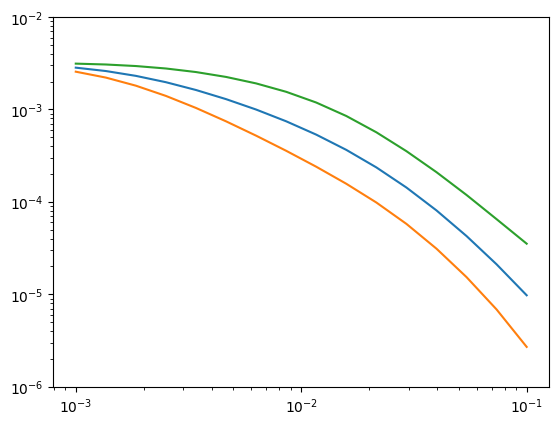

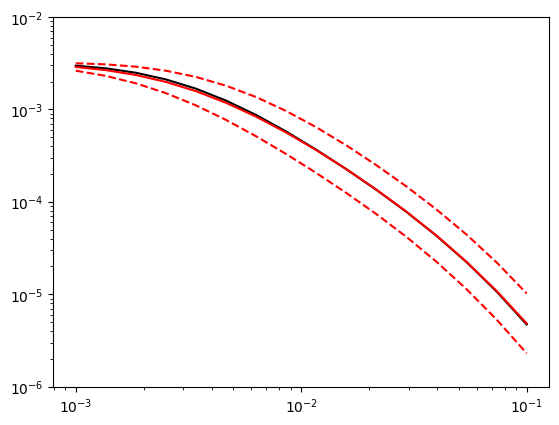

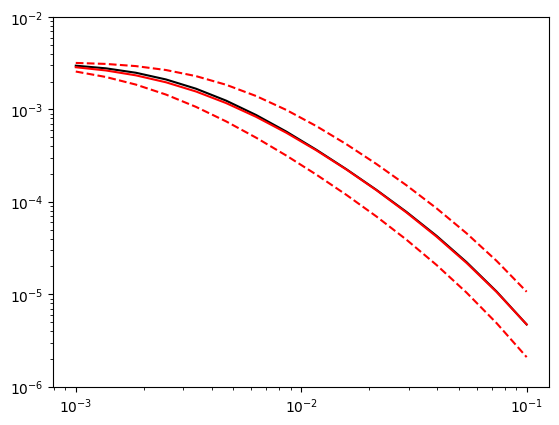

In [ ]:
dM = 0.05
haz_calc = HazCalculator(gmmlt, dM)
faults = [fault1]
median = haz_calc.calc_haz(ims, T, site, faults)
epi = haz_calc.calc_epi_haz(ims, T, site, faults)

scn_fault1_vec = Scenario(0., T, site, fault1).tree_tovec()
scn_fault2_vec = Scenario(0., T, site, fault2).tree_tovec()

n_KL_samples = 150
k_KL = 8
m_os_KL = 1.75
k_cheb_KL = 2
k_phs_KL = 2
k_poly_KL = 1
k_PCE = 1
k_taylor = 4
q = 0.65
n_PCE_samples = 500
n_eval = 100

params_idcs = jnp.array([0, 8])
params_transforms = [lambda x: x, jnp.exp]
params_a = jnp.array([5., 1.6])
params_b = jnp.array([8., 5.2])

def plottable(med, epi):
    return med, jnp.exp(jnp.log(med) - jnp.log(epi)), jnp.exp(jnp.log(med) + jnp.log(epi))

for arr in plottable(median, epi):
     plt.plot(ims, arr)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.show()